In [2]:
# Setup imports
import os
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Try importing XGBoost
try:
    import xgboost as xgb
except ImportError:
    xgb = None

import joblib

print("Setup Complete")

Setup Complete


In [3]:
# Loading data
import os
import pandas as pd

DATA_PATH = 'paysim.csv'

assert os.path.exists(DATA_PATH), "Dataset not found"

df = pd.read_csv(DATA_PATH)

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# Quick EDA

print("Shape:", df.shape)

print("\nData Types:\n", df.dtypes)

print("\nMissing Values:\n", df.isnull().sum())

print("\nClass Distribution:\n", df['isFraud'].value_counts())

print("\nFraud Ratio:", df['isFraud'].mean())

Shape: (6362620, 11)

Data Types:
 step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing Values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Class Distribution:
 isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Ratio: 0.001290820448180152


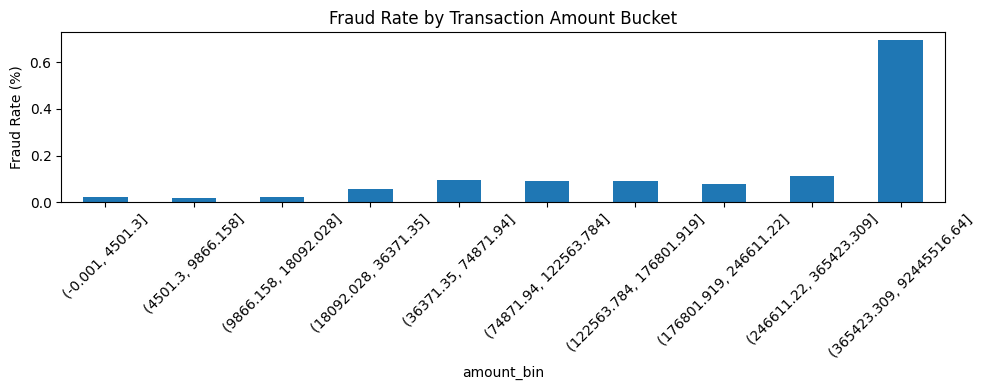

In [5]:
import matplotlib.pyplot as plt

# Create amount buckets (10 quantiles)
df['amount_bin'] = pd.qcut(df['amount'], q=10, duplicates='drop')

# Calculate fraud rate per bucket
fraud_rate = df.groupby('amount_bin')['isFraud'].mean()

# Convert to percentage
fraud_rate = fraud_rate * 100

# Plot
plt.figure(figsize=(10, 4))
fraud_rate.plot(kind='bar')

plt.ylabel("Fraud Rate (%)")
plt.title('Fraud Rate by Transaction Amount Bucket')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
# Checking missing values
print(df.isnull().sum())

# Checking merchant transactions (destination starting with 'M')
merchant_txns = df[df['nameDest'].str.startswith('M')]

merchant_txns[['oldbalanceDest', 'newbalanceDest']].describe()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
amount_bin        0
dtype: int64


,oldbalanceDest,newbalanceDest
count,2151495.0,2151495.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64


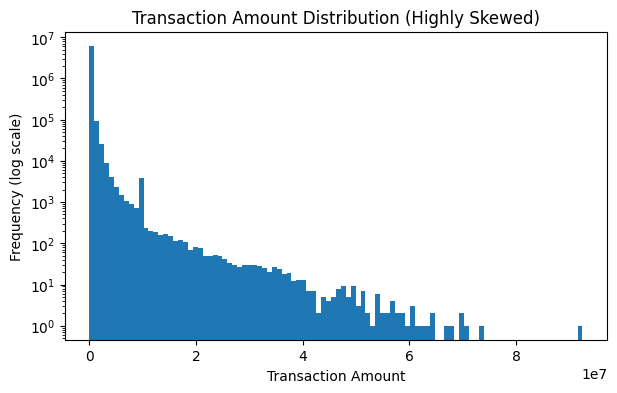

In [7]:
import matplotlib.pyplot as plt

# Summary statistics
print(df['amount'].describe())

# Visualize skewness
plt.figure(figsize=(7, 4))

plt.hist(df['amount'], bins=100)

plt.yscale('log')

plt.xlabel('Transaction Amount')
plt.ylabel('Frequency (log scale)')

plt.title('Transaction Amount Distribution (Highly Skewed)')

plt.show()

In [8]:
import numpy as np

# Log transform to reduce skewness
df['log_amount'] = np.log1p(df['amount'])

# Flag transactions above 99th percentile
p99 = df['amount'].quantile(0.99)

df['is_high_amount'] = (df['amount'] > p99).astype(int)

# Check counts
df['is_high_amount'].value_counts()

is_high_amount
0    6298993
1      63627
Name: count, dtype: int64

In [12]:
# is_high_amount flags the top 1% of transaction amounts, capturing extreme-value behavior
# that is often associated with fraudulent activity, while preserving the integrity of the dataset.

In [9]:
# Overview

total_txns = len(df)

fraud_txns = df['isFraud'].sum()

fraud_rate = fraud_txns / total_txns

fraud_pct = (df['isFraud'].sum() / total_txns) * 100

flagged_pct = (df['isFlaggedFraud'].sum() / total_txns) * 100

print(f"Total transactions: {total_txns:,}")

print(f"Fraud transactions: {fraud_txns:,}")

print(f"Overall fraud rate: {fraud_rate:.4f}")

print(f"Fraudulent transactions (isFraud=1): {fraud_pct:.4f}%")

print(f"Flagged transactions (isFlaggedFraud=1): {flagged_pct:.4f}%")

Total transactions: 6,362,620
Fraud transactions: 8,213
Overall fraud rate: 0.0013
Fraudulent transactions (isFraud=1): 0.1291%
Flagged transactions (isFlaggedFraud=1): 0.0003%


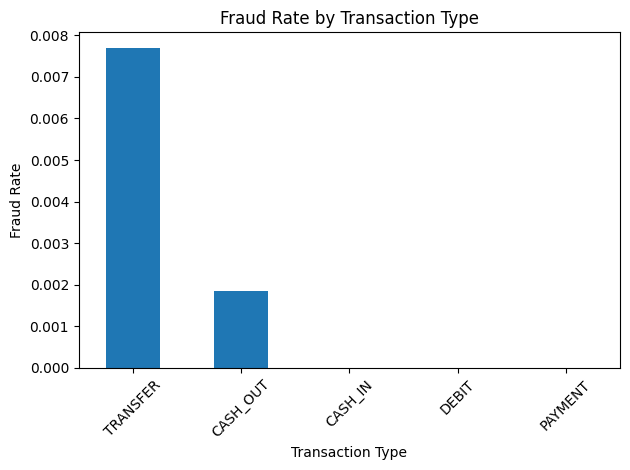

In [10]:
import matplotlib.pyplot as plt

# Fraud Rate by transaction type
df.groupby('type')['isFraud'].mean().sort_values(ascending=False).plot(kind='bar')

plt.title('Fraud Rate by Transaction Type')
plt.ylabel('Fraud Rate')
plt.xlabel('Transaction Type')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Create hour feature (assuming step is in hours)
df['hour'] = df['step'] % 24

# Aggregate hourly statistics
hourly_stats = (
    df.groupby('hour')
    .agg(
        total_transactions=('isFraud', 'count'),
        fraud_transactions=('isFraud', 'sum'),
        fraud_rate=('isFraud', 'mean')
    )
    .reset_index()
)

# Display result
display(hourly_stats.head())

,hour,total_transactions,fraud_transactions,fraud_rate
0,0,71587,300,0.004191
1,1,27111,358,0.013205
2,2,9018,372,0.041251
3,3,2007,326,0.162431
4,4,1241,274,0.220790


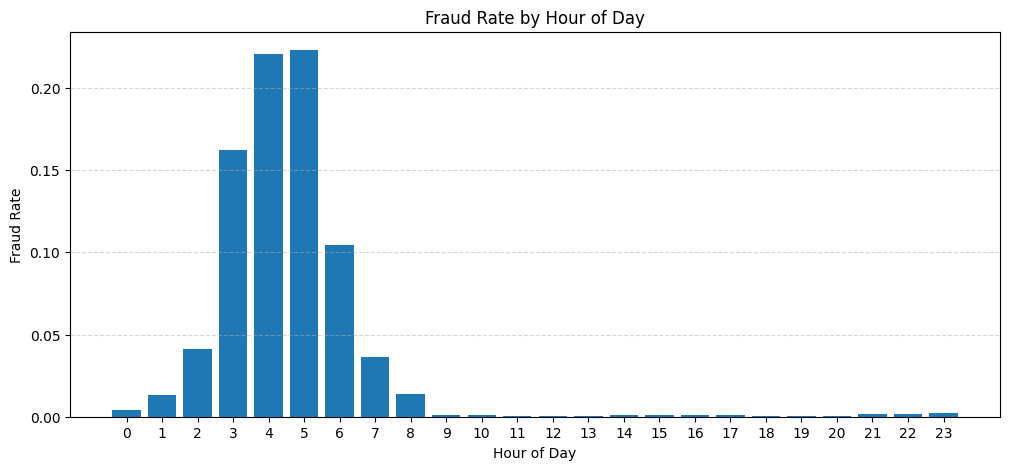

In [12]:
import matplotlib.pyplot as plt

# fraud rate by hour
plt.figure(figsize=(12, 5))

plt.bar(hourly_stats['hour'], hourly_stats['fraud_rate'])

plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of Day')

plt.xticks(range(0, 24))

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

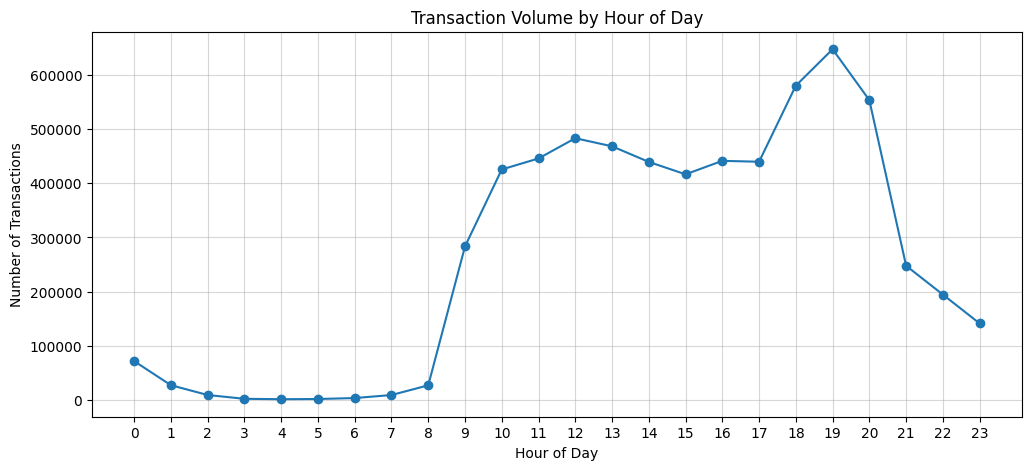

In [13]:
import matplotlib.pyplot as plt

# transaction volume by hour
plt.figure(figsize=(12, 5))

plt.plot(hourly_stats['hour'], hourly_stats['total_transactions'], marker='o')

plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.title('Transaction Volume by Hour of Day')

plt.xticks(range(0, 24))
plt.grid(alpha=0.5)

plt.show()

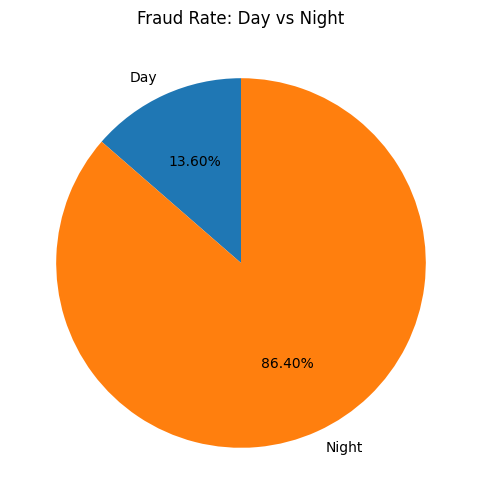

In [14]:
import matplotlib.pyplot as plt

# Day vs Night feature
df['is_night'] = df['hour'].isin([0, 1, 2, 3, 4, 5, 22, 23]).astype(int)

# Fraud rate comparison
day_night_fraud = (
    df.groupby('is_night')['isFraud']
    .mean()
    .rename(index={0: 'Day', 1: 'Night'})
)

# Pie chart
plt.figure(figsize=(6, 6))

day_night_fraud.plot(
    kind='pie',
    autopct='%1.2f%%',
    startangle=90,
    legend=False
)

plt.ylabel('')
plt.title('Fraud Rate: Day vs Night')

plt.show()

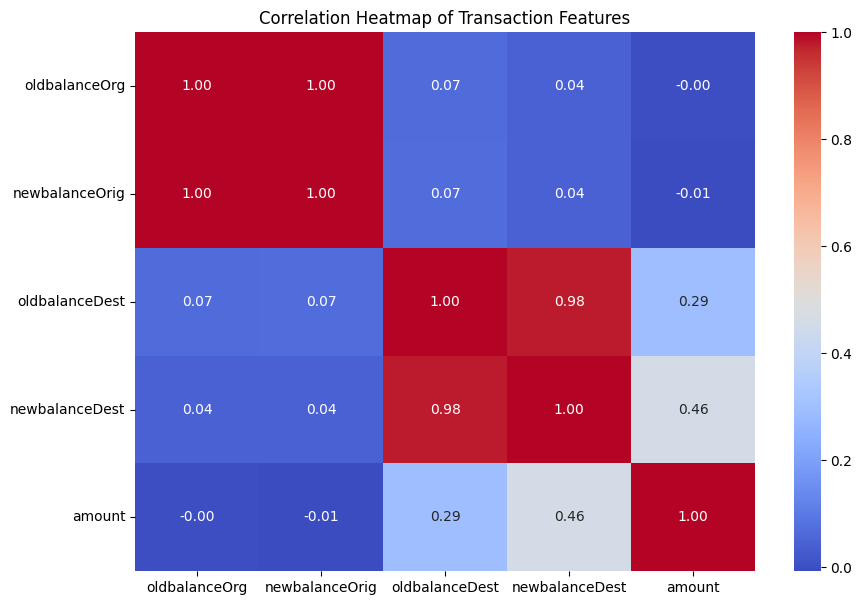

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot heatmap
plt.figure(figsize=(10, 7))
# Correlation matrix
corr = df[['oldbalanceOrg',
            'newbalanceOrig',
            'oldbalanceDest',
            'newbalanceDest',
            'amount']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Transaction Features')

plt.show()

This corellation matrix reveals severe multicollinearity between pre- and post-transaction balances, indicating redundancy. To address this balance -difference features were engineered and redundent variables need to be removed, improving model stability and interpretability.

FEATURE ENGINEERING AND DATA CLEANING

In [16]:
# Feature Engineering: Balance Differences

df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']

df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']


# Feature Reduction (for logistic regression / linear models)
df = df.drop(columns=[
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
])

In [17]:
from sklearn.preprocessing import LabelEncoder

# Drop unnecessary column
df.drop(columns=['amount_bin'], inplace=True)

# Handle missing values
df.fillna(0, inplace=True)

# Label encoding for transaction type
le = LabelEncoder()
df['type_enc'] = le.fit_transform(df['type'])

# Drop original categorical columns
df.drop(['nameOrig', 'nameDest', 'type'], axis=1, inplace=True)

TRAIN TEST SPLIT

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Features and target
X = df.drop(columns=['isFraud', 'isFlaggedFraud'])
y = df['isFraud'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Scaling
scaler = RobustScaler()

num_cols = X_train.select_dtypes(include=[np.number]).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

MODEL TRAINING AND EVALUATION

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {}

# =========================
# Logistic Regression
# =========================
print("Training Logistic Regression (fast mode)...")

lr = LogisticRegression(
    max_iter=300,
    solver='lbfgs',
    class_weight='balanced',
    n_jobs=-1
)

lr.fit(X_train, y_train)
models['LogisticRegression'] = lr

print("Logistic Regression trained")

# =========================
# Random Forest
# =========================
print("Training Random Forest (optimized)...")

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
    min_samples_leaf=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
models['Random Forest'] = rf

print("Random Forest trained")

# =========================
# XGBoost (optional)
# =========================
try:
    import xgboost as xgb

    print("Training XGBoost...")

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        n_jobs=-1
    )

    xgb_model.fit(X_train, y_train)
    models['XGBoost'] = xgb_model

    print("XGBoost trained")

except ImportError:
    print("XGBoost not installed")

Training Logistic Regression (fast mode)...
Logistic Regression trained
Training Random Forest (optimized)...
Random Forest trained
Training XGBoost...
XGBoost trained


In [20]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import pandas as pd

results = []

for name, model in models.items():

    # Get probability scores
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_test)[:, 1]
    else:
        scores = model.decision_function(X_test)

    print("\n", name)
    
    print(classification_report(y_test, (scores > 0.5).astype(int)))

    results.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, scores),
        "auprc": average_precision_score(y_test, scores)
    })

results_df = pd.DataFrame(results).sort_values('auprc', ascending=False)

results_df


 LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.89      0.05      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.93      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524


 Random Forest
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.07      0.96      0.12      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.97      0.56   1272524
weighted avg       1.00      0.98      0.99   1272524


 XGBoost
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.06      0.97      0.11      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.97      0.55   1272524
weighted avg       1.00    

,model,roc_auc,auprc
2,XGBoost,0.998036,0.871785
1,Random Forest,0.997632,0.841487
0,LogisticRegression,0.977524,0.550562


While all models achieve high ROC-AUC, PR-AUC reveals that XGBoost significantly outperforms others in identifying rare fraud cases, making it the best candidate for deployment in an imbalanced fraud detection setting

Turning the decision threshold 

In [21]:
from sklearn.metrics import precision_recall_curve

model = models['XGBoost']

y_scores = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Find threshold with recall 0.90 and best precision
candidates = [(t, p, r) for t, p, r in zip(thresholds, precision[:-1], recall[:-1])]

candidates = [c for c in candidates if c[2] >= 0.90]

best_threshold, best_p, best_r = max(candidates, key=lambda x: x[1])

print(f"Best threshold: {best_threshold:.4f}")

print(f"Precision: {best_p:.3f}, Recall: {best_r:.3f}")

Best threshold: 0.9081
Precision: 0.320, Recall: 0.900


After threshold optimization, the model flags transactions only when fraud probability exceeds 0.91. This achieves -90% fraud recall while improving precision to -35%, significantly reducing lake positives and operational review costs

FINE TUNING THE MODEL

In [22]:
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=200,
    max_depth=4,  # controls overfitting
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=50,  # critical for imbalance
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=200,
    min_samples_split=500,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42  # huge impact on precision
)

rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",200
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [25]:
lr_tuned = LogisticRegression(
    max_iter=300,
    solver='lbfgs',
    class_weight='balanced',
    C=0.3
)

# stronger regularization

lr_tuned.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.3
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [29]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate(model, X, y):
    scores = model.predict_proba(X)[:, 1]

    return {
        "ROC-AUC": roc_auc_score(y, scores),
        "PR-AUC": average_precision_score(y, scores)
    }

print("XGB:", evaluate(xgb_tuned, X_test, y_test))
print("RF:", evaluate(rf_tuned, X_test, y_test))
print("LR:", evaluate(lr_tuned, X_test, y_test))

XGB: {'ROC-AUC': 0.998193568409534, 'PR-AUC': 0.8638794884852592}
RF: {'ROC-AUC': 0.9977525113469301, 'PR-AUC': 0.8320049214362165}
LR: {'ROC-AUC': 0.9774936739612737, 'PR-AUC': 0.5504119584396516}


XGBoost is the best it catches most fraud with fewer false alarms , whilw random forest is slightly worse and logistic regression struggles with rare fraud


SAVING THE FINE TUNED MODEL


In [31]:
models = {
    "LogisticRegression": lr_tuned,
    "RandomForest": rf_tuned,
    "XGBoost": xgb_tuned
}

best_model_name = max(results, key=lambda x: x['auprc'])['model']
best_model = models[best_model_name]

best_model_artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "threshold": best_threshold,
    "features": X_train.columns.tolist()
}

import joblib

joblib.dump(best_model_artifact, "best_fraud_model_tuned.pkl")

print(f"Saved best model: {best_model_name}")
print(f"Decision threshold: {best_threshold:.4f}")

Saved best model: XGBoost
Decision threshold: 0.9081


TESTING

In [32]:
import joblib
import pandas as pd
from sklearn.metrics import confusion_matrix

# Load saved model artifact
artifact = joblib.load("best_fraud_model_tuned.pkl")

model = artifact["model"]
threshold = artifact["threshold"]
features = artifact["features"]

# Predict on test data
y_scores = model.predict_proba(X_test[features])[:, 1]
y_pred = (y_scores > threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Summary table
summary = pd.DataFrame({
    "Count": [tp, fn, fp, tn]
}, index=[
    "Correctly detected fraud (TP)",
    "Missed fraud (FN)",
    "False alarms (FP)",
    "Correct non-fraud (TN)"
])

print(summary)

# Quick fraud recall check
print(f"\nFraud Recall: {tp / (tp + fn):.3f}")
print(f"Fraud Precision: {tp / (tp + fp):.3f}")

                                 Count
Correctly detected fraud (TP)     1477
Missed fraud (FN)                  166
False alarms (FP)                 3712
Correct non-fraud (TN)         1267169

Fraud Recall: 0.899
Fraud Precision: 0.285


At an optimized threshold, the model achieves ~90% fraud recall with ~29% precision, meaning one in three flagged transactions is truly fraudulent. This significantly reduces false positives while maintaining strong fraud capture, which is ideal for production fraud systems. By minimizing false alarms, It also lowers operational costs and improves customer trust, enabling safer transactions and supporting business growth.

While testing correctly allowed -1.27 million legitimate transactions.

Precision: 29% Alerts: ~3,600 Missed fraud: only 169

That's a huge operational improvement....